# Introdução à Inteligência Artificial e Fundamentos de Python

## Regressão Linear em Aprendizado de Máquina

A Regressão Linear é um algoritmo fundamental de aprendizado de máquina supervisionado utilizado para modelar a relação entre uma variável dependente e uma ou mais variáveis ​​independentes. Ela prevê novos valores com base em uma linha reta que ajusta as variáveis independentes às dependentes. O algoritmo determina esta reta com base nos dados fornecidos, onde:
* é assumida a existência de uma relação linear entre a entrada e a saída,
* calcula uma linha de melhor ajuste para realizar previsões.
  
A regressão Linear é  comumente utilizada em previsões, análise de tendências e modelagem preditiva.

Como Exemplo, considere um conjunto de dados de entrada onde a variável independente é representada pela coordenada *x* e a variável independente é representada pela coordenada *y* de pontos no plano. Assim os pontos são descritos por pares coordenados (*x*,*y*) no qual *x* identifica por exemplo o número de horas de estudo dos alunos de uma turma e *y* corresponde à média obtida. Considere que esta relação é linear. Então, o ajuste calculado poderia resultar em algo como mostra a figura abaixo:

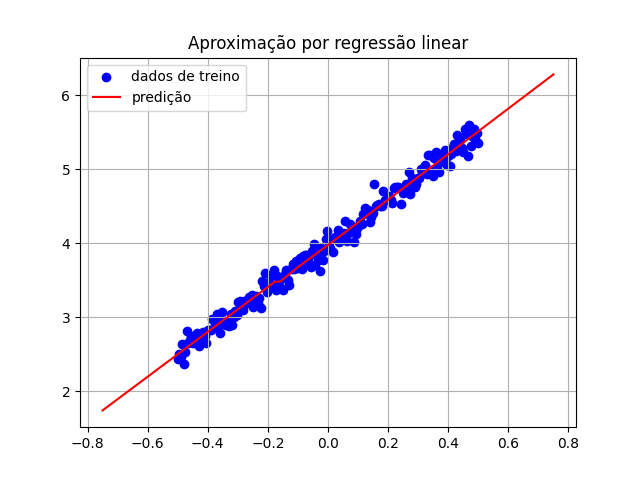

Os dados de treino são os pares coordenados utilizados para obter a reta mostrada. Com esta reta é possível, em tese, prever a nota de um aluno com base nas hora utilizadas em estudo. 

Assim, o conjunto de dados disponíveis inicialmente (pontos coordenados) são os dados de treino, os quais são utilizados para o cálculo das varíaveis $\beta_0$ e $\beta_1$ de forma que

$$y(x)=\beta_0+\beta_1x$$

onde $\beta_0$ é a intercecção da reta no eixo *y*, ou seja, $y(0)$, e $\beta_1$ é o coeficiente angular da reta. 

Na regressão linear, uma **Função Custo** mede quão distantes os valores previstos (na reta) $\hat{y}$ estão dos valores *y* reais. A função mais comum é a função *Erro Quadrático Médio-MSE*, que calcula a média das diferenças entre os valores reais e previstos elevadas ao quadrado:

$$J=\frac{1}{n}\sum_{i=1}^n(y_i-\hat{y}_i)^2$$

Finalmente, procura-se encontrar pesos $\beta$ que minimizem esta função. Uma técnica popular é o método dos *Gradientes Descendentes*. Nesta introdução vamos estudar a minimização da função custo através da solução analítica do problema. 

* Vamos supor inicialmente um conjunto de dados observados $(X_i,y_i)$, e supondo que as coordenadas sejam linearmente relacionadas, queremos encontrar $\hat{y}(x)=\beta_0+\beta_1x$, ou seja os coeficientes de forma que o erro seja mínimo. Como exemplo, suponha os dados (1,2),(2,3) e (3,5). Com esses dados podemos criar a matriz $$X=\begin{bmatrix}1&1\\1&2\\1&3\end{bmatrix}$$. 







In [1]:
import numpy as np
X_b=np.array([[1],[2],[3]])
print(X_b)

[[1]
 [2]
 [3]]


In [2]:
X_b=np.c_[np.ones((3,1)),X_b]
print(X_b)

[[1. 1.]
 [1. 2.]
 [1. 3.]]


Nos comandos acima, np.c_ significa concatenação por coluna, assim como np.r_ significa concatenação por linha. 

Agora o motivo de termos concatenado a coluna de 1s ao vetor $X_b$: queremos prever valores de forma que $$\hat{y}=X_b\beta,$$
onde $X_b$ é a matriz formada acima e $\beta=\begin{bmatrix}\beta_0\\\beta_1\end{bmatrix}$, de forma que tenhamos como resultado 
$$\begin{bmatrix}1&1\\1&2\\1&3\end{bmatrix}\begin{bmatrix}\beta_0\\\beta_1\end{bmatrix}=\begin{bmatrix}\beta_0+\beta_1\\\beta_0+2\beta_1\\\beta_0+3\beta_1\end{bmatrix}.$$

Os  coeficientes são encontrados minimizando 
$$J=(y-X_b\beta)^T(y-X_b\beta),\quad \text{que pode ser expandido como}$$
$$J=y^Ty-y^TX_b\beta-\beta^TX_b^Ty+\beta^TX_b^TX_b\beta$$
os dois termos centrais são iguais (o primeiro é a transposta do segundo, ou vice-versa, e resultado é um escalar), portanto
$$J=y^Ty-2\beta^TX_b^Ty+\beta^TX_b^TX_b\beta$$

Derivando com relação á matriz $\beta$ e igualando a zero, teremos

$$\frac{\partial J}{\partial\beta}=-2X_b^Ty+2X_b^TX_b\beta=0$$
de forma que $X_b^TX\beta=X_b^Ty$ é a equação normal, a partir da qual isolando $\beta$ teremos a solução desejada:
$$\beta=(X_b^TX_b)^{-1}X_b^Ty$$ 

In [3]:
XX=X_b.T.dot(X_b)
print(XX)

[[ 3.  6.]
 [ 6. 14.]]


In [4]:
y=np.array([[2],[3],[5]])
xy=X_b.T.dot(y)
print(xy)

[[10.]
 [23.]]


A inversa de xx é:

In [5]:
XX_inv=np.linalg.inv(XX)
print(XX_inv)

[[ 2.33333333 -1.        ]
 [-1.          0.5       ]]


finalmente, 

In [6]:
y=XX_inv.dot(xy)
print(y)

[[0.33333333]
 [1.5       ]]


ou seja, 
$$\hat{y}=0.333+1,5x$$